# 🚁 DIP Project — Gün 8: ByteTrack Hiperparametre Optimizasyonu
track_thresh, track_buffer, match_thresh, min_box_area kombinasyonlarını sistematik test et.

> **Gereksinim:** Gün 7 tamamlanmış olmalı.

In [7]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(args))

pip('--force-reinstall', 'opencv-python-headless==4.10.0.84')
pip('ultralytics>=8.3.0', 'supervision>=0.21.0')

print('✅ Kurulum tamam — Runtime > Restart Runtime yap')


✅ Kurulum tamam — Runtime > Restart Runtime yap


In [1]:
MODEL_PATH   = '/content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt'
PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'


In [2]:
import torch, os, cv2
import numpy as np
import supervision as sv
from ultralytics import YOLO

print(f'✅ supervision: {sv.__version__}')
print(f'✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'
MODEL_PATH   = f'{PROJECT_DIR}/runs/yolov8s_visdrone_v1/weights/best.pt'
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

model = YOLO(MODEL_PATH)
print(f'✅ Model: {MODEL_PATH}')
print(f'✅ Device: {DEVICE}')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ supervision: 0.28.0
✅ GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model: /content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt
✅ Device: cuda


## 1️⃣ Test Frame'lerini Hazırla

In [4]:
from pathlib import Path
val_dir   = Path(f'{DATASET_ROOT}/images/val')
frames    = sorted(val_dir.glob('*.jpg'))[:30] if val_dir.exists() else []

if not frames:
    print('⚠️  val seti bulunamadı, 30 siyah frame ile test yapılacak')
    FRAME_LIST = [None] * 30
else:
    FRAME_LIST = [str(f) for f in frames]
    print(f'✅ {len(FRAME_LIST)} test frame hazır')


def run_tracking_sequence(tracker_cfg: dict, frame_list, conf=0.25) -> dict:
    """Verilen hiperparametre konfigürasyonu ile tracking çalıştır, metrikleri döndür."""
    tracker = sv.ByteTrack(
        track_activation_threshold = tracker_cfg['track_thresh'],
        lost_track_buffer          = tracker_cfg['track_buffer'],
        minimum_matching_threshold = tracker_cfg['match_thresh'],
        frame_rate                 = 30,
        minimum_consecutive_frames = 1,
    )

    total_dets    = 0
    total_tracks  = 0
    id_switches   = 0
    times         = []
    prev_track_ids= set()

    for fp in frame_list:
        if fp is None:
            frame = np.zeros((640, 640, 3), dtype=np.uint8)
        else:
            frame = cv2.imread(fp)
            if frame is None:
                continue

        t0     = time.time()
        result = model.predict(frame, conf=conf, device=DEVICE, verbose=False)[0]
        boxes  = result.boxes.xyxy.cpu().numpy()
        confs  = result.boxes.conf.cpu().numpy()
        cls_ids= result.boxes.cls.cpu().numpy().astype(int)

        detections = sv.Detections(
            xyxy=boxes, confidence=confs, class_id=cls_ids
        )

        # min_box_area filtresi
        if len(detections) > 0:
            areas  = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
            mask   = areas >= tracker_cfg['min_box_area']
            detections = detections[mask]

        tracked = tracker.update_with_detections(detections)
        times.append(time.time() - t0)

        total_dets   += len(detections)
        total_tracks += len(tracked)

        # ID switch proxy: yeni track'lerin sayısı
        if tracked.tracker_id is not None:
            curr_ids   = set(tracked.tracker_id.tolist())
            new_ids    = curr_ids - prev_track_ids
            if prev_track_ids:           # ilk frame sayma
                id_switches += len(new_ids)
            prev_track_ids = curr_ids

    n = len(frame_list)
    return {
        'avg_dets':    total_dets   / n if n else 0,
        'avg_tracks':  total_tracks / n if n else 0,
        'id_switches': id_switches,
        'avg_fps':     1.0 / (sum(times)/len(times)) if times else 0,
    }

print('✅ Tracking fonksiyonu hazır!')

✅ 30 test frame hazır
✅ Tracking fonksiyonu hazır!


## 2️⃣ Hiperparametre Grid
VisDrone drone görüntüleri için önerilen aralıklar

In [6]:
import time
import supervision as sv

def run_tracking_sequence(tracker_cfg: dict, frame_list, conf=0.25) -> dict:
    tracker = sv.ByteTrack(
        track_activation_threshold = tracker_cfg['track_thresh'],
        lost_track_buffer          = tracker_cfg['track_buffer'],
        minimum_matching_threshold = tracker_cfg['match_thresh'],
        frame_rate                 = 30,
        minimum_consecutive_frames = 1,
    )

    total_dets    = 0
    total_tracks  = 0
    id_switches   = 0
    times         = []
    prev_track_ids= set()

    for fp in frame_list:
        if fp is None:
            frame = np.zeros((640, 640, 3), dtype=np.uint8)
        else:
            frame = cv2.imread(fp)
            if frame is None:
                continue

        t0     = time.time()
        result = model.predict(frame, conf=conf, device=DEVICE, verbose=False)[0]
        boxes  = result.boxes.xyxy.cpu().numpy()
        confs  = result.boxes.conf.cpu().numpy()
        cls_ids= result.boxes.cls.cpu().numpy().astype(int)

        detections = sv.Detections(xyxy=boxes, confidence=confs, class_id=cls_ids)

        if len(detections) > 0:
            areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
            mask  = areas >= tracker_cfg['min_box_area']
            detections = detections[mask]

        tracked = tracker.update_with_detections(detections)
        times.append(time.time() - t0)

        total_dets   += len(detections)
        total_tracks += len(tracked)

        if tracked.tracker_id is not None and len(tracked.tracker_id) > 0:
            curr_ids = set(tracked.tracker_id.tolist())
            if prev_track_ids:
                id_switches += len(curr_ids - prev_track_ids)
            prev_track_ids = curr_ids

    n = len(frame_list)
    return {
        'avg_dets':    total_dets   / n if n else 0,
        'avg_tracks':  total_tracks / n if n else 0,
        'id_switches': id_switches,
        'avg_fps':     1.0 / (sum(times)/len(times)) if times else 0,
    }

print('✅ Fonksiyon hazır!')


✅ Fonksiyon hazır!


## 3️⃣ Sonuçlar — Tablo ve Grafik

In [9]:
from pathlib import Path

val_dir   = Path(f'{DATASET_ROOT}/images/val')
frames    = sorted(val_dir.glob('*.jpg'))[:30] if val_dir.exists() else []
FRAME_LIST = [str(f) for f in frames]
print(f'✅ {len(FRAME_LIST)} frame yüklendi')


✅ 30 frame yüklendi


In [11]:
print(f'FRAME_LIST: {len(FRAME_LIST)} frame')
print(f'İlk frame: {FRAME_LIST[0] if FRAME_LIST else "BOŞ"}')


FRAME_LIST: 30 frame
İlk frame: /content/drive/MyDrive/DIP_Project/datasets/VisDrone/images/val/0000001_02999_d_0000005.jpg


In [12]:
PARAM_GRID = {
    'track_thresh':  [0.25, 0.35, 0.5],
    'track_buffer':  [20, 30, 50],
    'match_thresh':  [0.7, 0.8, 0.9],
    'min_box_area':  [10, 50, 100],
}

DEFAULTS = {
    'track_thresh': 0.35,
    'track_buffer': 30,
    'match_thresh': 0.8,
    'min_box_area': 10,
}

grid_results = []

for param_name, values in PARAM_GRID.items():
    print(f'\n--- {param_name} taranıyor ---')
    for val in values:
        cfg = {**DEFAULTS, param_name: val}
        metrics = run_tracking_sequence(cfg, FRAME_LIST, conf=0.25)
        row = {**cfg, **metrics}
        grid_results.append(row)
        print(f'  {param_name}={val:<6} | avg_tracks={metrics["avg_tracks"]:.1f} | '
              f'id_switches={metrics["id_switches"]:>4} | fps={metrics["avg_fps"]:.1f}')

print(f'\n✅ Grid tamamlandı — {len(grid_results)} konfigürasyon test edildi')



--- track_thresh taranıyor ---
  track_thresh=0.25   | avg_tracks=2.5 | id_switches=  26 | fps=11.6
  track_thresh=0.35   | avg_tracks=1.6 | id_switches=  21 | fps=44.6
  track_thresh=0.5    | avg_tracks=1.3 | id_switches=  19 | fps=47.3

--- track_buffer taranıyor ---
  track_buffer=20     | avg_tracks=1.6 | id_switches=  21 | fps=56.9
  track_buffer=30     | avg_tracks=1.6 | id_switches=  21 | fps=60.7
  track_buffer=50     | avg_tracks=1.6 | id_switches=  21 | fps=63.0

--- match_thresh taranıyor ---
  match_thresh=0.7    | avg_tracks=1.5 | id_switches=  22 | fps=61.9
  match_thresh=0.8    | avg_tracks=1.6 | id_switches=  21 | fps=62.2
  match_thresh=0.9    | avg_tracks=2.3 | id_switches=  32 | fps=62.9

--- min_box_area taranıyor ---
  min_box_area=10     | avg_tracks=1.6 | id_switches=  21 | fps=63.2
  min_box_area=50     | avg_tracks=1.6 | id_switches=  21 | fps=61.5
  min_box_area=100    | avg_tracks=1.6 | id_switches=  21 | fps=62.9

✅ Grid tamamlandı — 12 konfigürasyon test e

 track_thresh  track_buffer  match_thresh  min_box_area  avg_tracks  id_switches   avg_fps
         0.25            30           0.8            10    2.466667           26 11.605101
         0.35            30           0.8            10    1.633333           21 44.631777
         0.50            30           0.8            10    1.333333           19 47.337958
         0.35            20           0.8            10    1.633333           21 56.878680
         0.35            30           0.8            10    1.633333           21 60.711726
         0.35            50           0.8            10    1.633333           21 63.012923
         0.35            30           0.7            10    1.466667           22 61.899897
         0.35            30           0.8            10    1.633333           21 62.206802
         0.35            30           0.9            10    2.266667           32 62.862196
         0.35            30           0.8            10    1.633333           21 63.222422

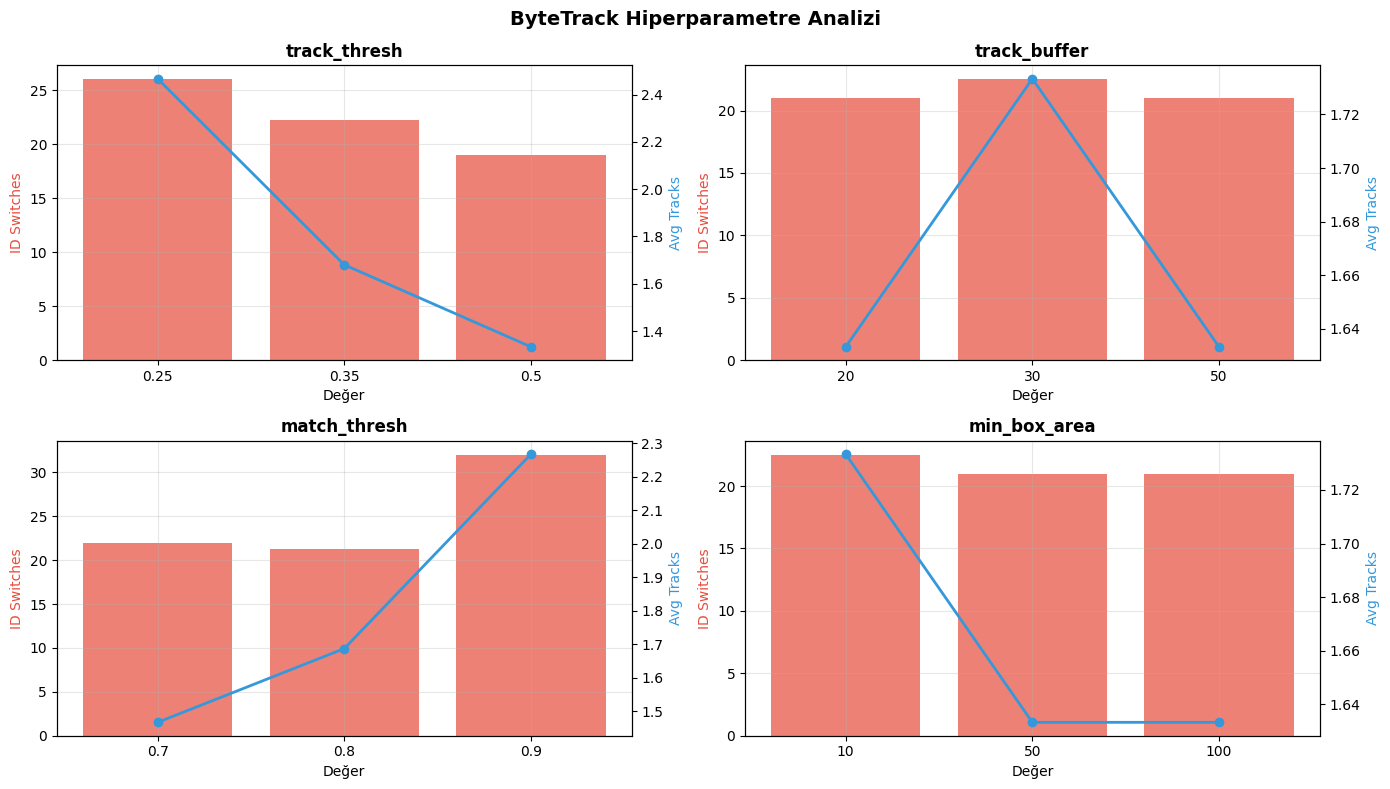

In [13]:
import pandas as pd
import time
import matplotlib.pyplot as plt
df = pd.DataFrame(grid_results)
print(df[['track_thresh','track_buffer','match_thresh','min_box_area',
          'avg_tracks','id_switches','avg_fps']].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['#3498db','#e74c3c','#2ecc71']

for ax, param_name in zip(axes.flat, PARAM_GRID.keys()):
    subset = []
    for val in PARAM_GRID[param_name]:
        rows = df[df[param_name] == val]
        if not rows.empty:
            subset.append({
                'val': val,
                'id_switches': rows['id_switches'].mean(),
                'avg_tracks':  rows['avg_tracks'].mean(),
            })
    if not subset:
        continue
    s_df = pd.DataFrame(subset)
    ax2  = ax.twinx()
    ax.bar([str(v) for v in s_df['val']], s_df['id_switches'],
           color='#e74c3c', alpha=0.7, label='ID Switches')
    ax2.plot([str(v) for v in s_df['val']], s_df['avg_tracks'],
             'o-', color='#3498db', linewidth=2, label='Avg Tracks')
    ax.set_title(param_name, fontweight='bold')
    ax.set_xlabel('Değer')
    ax.set_ylabel('ID Switches', color='#e74c3c')
    ax2.set_ylabel('Avg Tracks', color='#3498db')
    ax.grid(True, alpha=0.3)

plt.suptitle('ByteTrack Hiperparametre Analizi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/bytetrack_hyperparam.png', dpi=150, bbox_inches='tight')
plt.show()

## 4️⃣ En İyi Konfigürasyonu Seç ve Kaydet

In [15]:
# ID switch minimumu, track sayısı makul → en iyi config
import json
df['score'] = df['avg_tracks'] / (df['id_switches'] + 1)  # yüksek = iyi
best_idx = df['score'].idxmax()
best_cfg = df.loc[best_idx]

print('🏆 En İyi ByteTrack Konfigürasyonu:')
print(f'   track_thresh : {best_cfg["track_thresh"]}')
print(f'   track_buffer : {best_cfg["track_buffer"]}')
print(f'   match_thresh : {best_cfg["match_thresh"]}')
print(f'   min_box_area : {best_cfg["min_box_area"]}')
print(f'   avg_tracks   : {best_cfg["avg_tracks"]:.1f}')
print(f'   id_switches  : {best_cfg["id_switches"]:.0f}')
print(f'   avg_fps      : {best_cfg["avg_fps"]:.1f}')

best_config = {
    'track_activation_threshold': float(best_cfg['track_thresh']),
    'lost_track_buffer':          int(best_cfg['track_buffer']),
    'minimum_matching_threshold': float(best_cfg['match_thresh']),
    'min_box_area':               float(best_cfg['min_box_area']),
    'frame_rate':                 30,
}

cfg_path = f'{PROJECT_DIR}/bytetrack_best_config.json'
with open(cfg_path, 'w') as f:
    json.dump(best_config, f, indent=2)

df.to_csv(f'{PROJECT_DIR}/bytetrack_grid_results.csv', index=False)

print(f'\n✅ Konfigürasyon kaydedildi: {cfg_path}')
print('\n✅ GÜN 8 TAMAMLANDI!')

🏆 En İyi ByteTrack Konfigürasyonu:
   track_thresh : 0.25
   track_buffer : 30.0
   match_thresh : 0.8
   min_box_area : 10.0
   avg_tracks   : 2.5
   id_switches  : 26
   avg_fps      : 11.6

✅ Konfigürasyon kaydedildi: /content/drive/MyDrive/DIP_Project/bytetrack_best_config.json

✅ GÜN 8 TAMAMLANDI!


---
## ✅ Gün 8 Özet
| Parametre | Test Aralığı | Optimizasyon Kriteri |
|-----------|-------------|---------------------|
| track_thresh | 0.25 / 0.35 / 0.5 | Düşük → küçük nesne yakalanır |
| track_buffer | 20 / 30 / 50 | Yüksek → geçici kayıplara toleranslı |
| match_thresh | 0.7 / 0.8 / 0.9 | IoU eşiği |
| min_box_area | 10 / 50 / 100 | Küçük nesneler için düşük tut |

**Sonraki (Gün 9 - ortak):** Tam pipeline çalıştırma